# **EBPP Final Project:** Hierarchical Bayesian Analysis of Player Impact

Case Study: Nikola Mirotić & FC Barcelona Basketball (2021/2022 Season)

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

# if error or warning about g++, on conda prompt:
# conda install -c conda-forge gxx_linux-64
# or
# conda install -c conda-forge m2w64-toolchain

In [2]:
# Set visualization parameters
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

# Fix random seed for reproducibility across MCMC samplers
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Data loading

In [3]:
df = pd.read_csv("data/Data_AllSeason.csv")

headers = ['play_id', 'point_guard', 'shooting_guard', 'small_forward', 'power_forward', 'center', 'points_difference',
           'play_type', 'good_shot', 'points', 'quarter', 'clutch', 'opponent', 'court', 'competition']
df.columns = headers

display(df)

,play_id,point_guard,shooting_guard,small_forward,power_forward,center,points_difference,play_type,good_shot,points,quarter,clutch,opponent,court,competition
0,1,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,0,2,1,2,1,0,Alba Berlin,Local,Eurolliga
1,2,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,2,2,1,3,1,0,Alba Berlin,Local,Eurolliga
2,3,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,2,1,0,Alba Berlin,Local,Eurolliga
3,4,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,3,1,0,Alba Berlin,Local,Eurolliga
4,5,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,8,4,1,0,1,0,Alba Berlin,Local,Eurolliga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3637,3638,Calathes,Higgins,Abrines,Mirotic,Sanli,7,4,1,2,4,0,Olympiacos,Neutral,F4
3638,3639,Calathes,Higgins,Abrines,Mirotic,Sanli,6,4,0,0,4,1,Olympiacos,Neutral,F4
3639,3640,Calathes,Higgins,Abrines,Mirotic,Sanli,5,2,1,2,4,1,Olympiacos,Neutral,F4
3640,3641,Calathes,Higgins,Abrines,Mirotic,Sanli,7,1,1,2,4,0,Olympiacos,Neutral,F4


We create a DataFrame only containing the plays where Mirotic was present on the court and another one for Davies.

In [4]:
# Construct indicators tracking presence of Mirotic vs baseline rotations
df['has_mirotic'] = df.apply(lambda row: int('Mirotic' in [row['point_guard'], row['shooting_guard'], 
                                                           row['small_forward'], row['power_forward'], 
                                                           row['center']]), axis=1)

print(f"Total processed dataset dimensions: {df.shape}")
print(f"Mirotić line-up sample entries: {df['has_mirotic'].sum()} plays.")

Total processed dataset dimensions: (3642, 16)
Mirotić line-up sample entries: 2132 plays.


In [5]:
df_mirotic = df[(df['has_mirotic'] == 1)]

# display(df_mirotic)

df_no_mirotic = df[(df['has_mirotic'] != 1)]

# display(df_no_mirotic)

In [6]:
# Encode categorical variables into indexing matrices for hierarchy mapping
# Define our target hierarchy categories: combination of court position and clutch time

df['strat_group'] = df['court'].astype(str) + "_" + df['clutch'].astype(str)
group_names = df['strat_group'].unique()
group_idx = pd.Categorical(df['strat_group']).codes
num_groups = len(group_names)

print(f"Extracted {num_groups} distinct operational environment strata indices:")
for idx, name in enumerate(group_names):
    print(f" Index {idx} -> Stratum Profile: {name} (N={np.sum(group_idx == idx)})")

Extracted 6 distinct operational environment strata indices:
 Index 0 -> Stratum Profile: Local_0 (N=1638)
 Index 1 -> Stratum Profile: Visitant_0 (N=193)
 Index 2 -> Stratum Profile: Visitant_1 (N=88)
 Index 3 -> Stratum Profile: Local_1 (N=94)
 Index 4 -> Stratum Profile: Neutral_1 (N=1515)
 Index 5 -> Stratum Profile: Neutral_0 (N=114)


In [7]:
df.head()

,play_id,point_guard,shooting_guard,small_forward,power_forward,center,points_difference,play_type,good_shot,points,quarter,clutch,opponent,court,competition,has_mirotic,strat_group
0,1,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,0,2,1,2,1,0,Alba Berlin,Local,Eurolliga,1,Local_0
1,2,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,2,2,1,3,1,0,Alba Berlin,Local,Eurolliga,1,Local_0
2,3,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,2,1,0,Alba Berlin,Local,Eurolliga,1,Local_0
3,4,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,3,1,0,Alba Berlin,Local,Eurolliga,1,Local_0
4,5,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,8,4,1,0,1,0,Alba Berlin,Local,Eurolliga,1,Local_0


# Non-Hierarchical Model Setup

## 1. Exploration of the `good_shot` column

In [8]:
# Case M)
case_m = df_mirotic['good_shot'] == 1

y_m = case_m.sum()
pi_hat_m = case_m.mean()

print("- Mirotic Case (good_shot = 1):")
print(f"Number of successes: {y_m} of {len(df_mirotic)}")
print(f"Sample proportion: {pi_hat_m}\n")


# Case D)
case_n = df_no_mirotic['good_shot'] == 1

y_n = case_n.sum()
pi_hat_n = case_n.mean()

print("- No Mirotic Case (good_shot = 1):")
print(f"Number of successes: {y_n} of {len(df_no_mirotic)}")
print(f"Sample proportion: {pi_hat_n}")

- Mirotic Case (good_shot = 1):
Number of successes: 1417 of 2132
Sample proportion: 0.6646341463414634

- No Mirotic Case (good_shot = 1):
Number of successes: 910 of 1510
Sample proportion: 0.6026490066225165


Now, we will check the proportion of good shots for the general dataset, so that later we can have an informed prior:

In [9]:
general_case = df['good_shot'] == 1

y_g = general_case.sum()
pi_hat_g = general_case.mean()

print("- General Case (good_shot = 1):")
print(f"Number of successes: {y_g} of {len(df)}")
print(f"Sample proportion: {pi_hat_g}\n")

- General Case (good_shot = 1):
Number of successes: 2327 of 3642
Sample proportion: 0.6389346512904998



## 2. Model choice

Observe that we only have two options (Success or Failure) for a fixed population in both cases, which clearly follows a Binomial distribution. Moreover, since our goal is to estimate a proportion and the Beta distribution is defined in the interval $[0 , 1]$, this makes the **Beta-Binomial** distribution a clear option.

Therefore, we have the following Bayesian model for each case:
- Mirotic Case:
$$
Y_M \mid \pi_M \sim \mathrm{Binomial}(2132,\pi_M),
\qquad
\pi_M \sim \mathrm{Beta}(\alpha,\beta).
$$

- No Mirotic Case:
$$
Y_N \mid \pi_N \sim \mathrm{Binomial}(1510,\pi_N),
\qquad
\pi_N \sim \mathrm{Beta}(\alpha,\beta).
$$
Where $Y_M$ and $Y_N$ are the observed number of successes, $\pi_M$ and $\pi_N$ are the unknown true population proportion, and $n_M=2132$ and $n_D=1510$ are the total sample size for the Mirotic and No Mirotic case respectively.

## 3. Prior definition

We chose an **Empirical Bayes** prior based on the team's overall success rate ($p = 0.63$) seen before. We set the prior strength to $N = 70$ (about 3-4% of our total data), which provides a stable baseline without overwhelming the actual evidence from the data. We apply the same prior to both cases to ensure a fair comparison.

**Prior distribution:**
$\pi \sim \operatorname{Beta}(\alpha, \beta)$

**Parameters:**
- $\alpha = 0.63 \times 70 = 44.1$
- $\beta = 0.37 \times 70 = 25.9$

By using $\operatorname{Beta}(44.1, 25.9)$ for both groups, any difference we find in the posterior distributions will be strictly due to Mirotic's specific impact on the game.

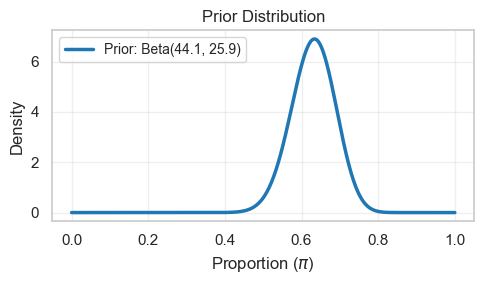

In [10]:
from scipy.stats import beta

x = np.linspace(0, 1, 500)

y_informative = beta.pdf(x, 44.1, 25.9)

plt.figure(figsize=(5, 3))

plt.plot(x, y_informative, label='Prior: Beta(44.1, 25.9)', color='#1f77b4', lw=2.5)

plt.title('Prior Distribution')
plt.xlabel('Proportion ($\pi$)')
plt.ylabel('Density')

plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Posterior Distribution

Since our priors are of the form $\pi \sim \operatorname{Beta}(\alpha,\beta)$ and the data follows a Binomial distribution $Y \sim \operatorname{Binomial}(n,\pi)$, we can obtain the posterior distributions analytically. This is done by adding the number of successes ($Y$) to $\alpha$ and the number of failures ($n - Y$) to $\beta$:

$$
\pi \mid Y \sim \operatorname{Beta}(\alpha + Y, \beta + n - Y)
$$

In our case, we use the previously defined informative prior $\operatorname{Beta}(44.1, 25.9)$. Based on the dataset:

- **Case M (Mirotic on court):**
    - $n_M = 2132$, $Y_M = 1417$
    - **Posterior:** $\operatorname{Beta}(44.1 + Y_M, 25.9 + n_M - Y_M)$

- **Case N (Mirotic off court):**
    - $n_N = 1510$, $Y_N = 910$
    - **Posterior:** $\operatorname{Beta}(44.1 + Y_N, 25.9 + n_N - Y_N)$

In the next cell, we visualize how the team's global prior is updated with the specific data from each case.

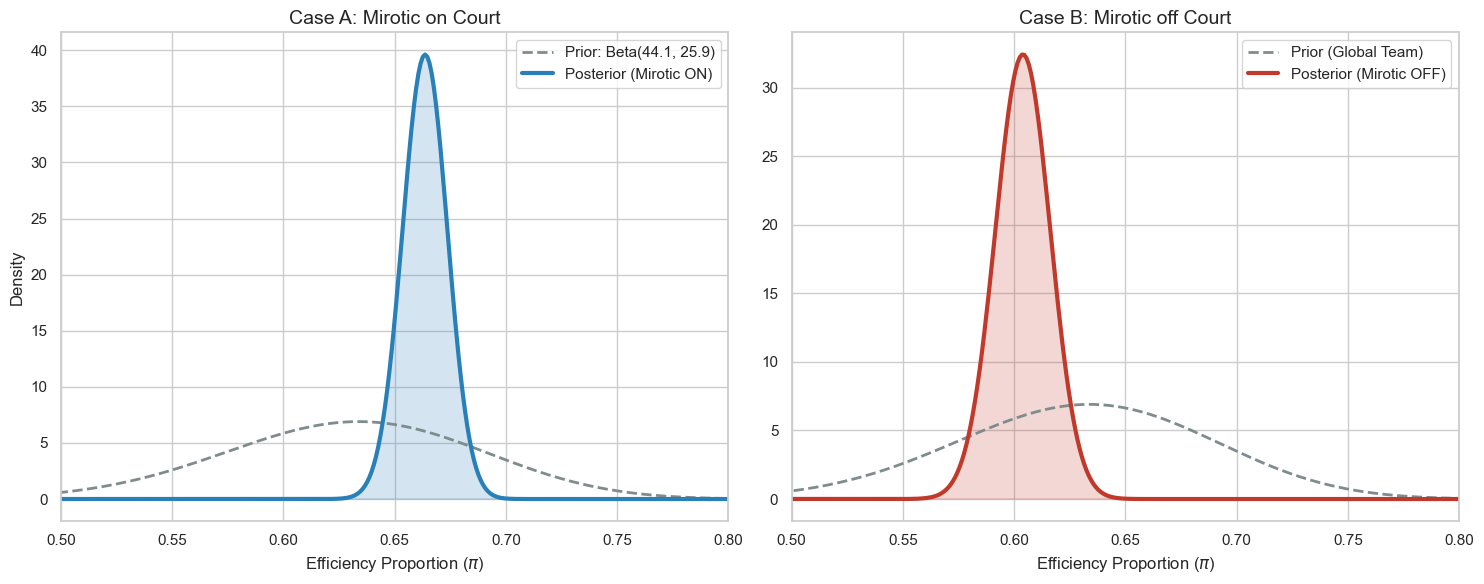

In [11]:
from scipy.stats import beta

# Case M: Mirotic on court
n_M = len(df_mirotic)
Y_M = df_mirotic['good_shot'].sum()

# Case N: No Mirotic on court
n_N = len(df_no_mirotic)
Y_N = df_no_mirotic['good_shot'].sum()

# Prior definition
alpha_prior, beta_prior = 44.1, 25.9

# Posterior calculation
alpha_post_M, beta_post_M = alpha_prior + Y_M, beta_prior + (n_M - Y_M)
alpha_post_N, beta_post_N = alpha_prior + Y_N, beta_prior + (n_N - Y_N)

# --- VISUALIZATION ---
x = np.linspace(0, 1, 1000)
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

c_prior = '#7f8c8d'
c_post_M = '#2980b9'
c_post_N = '#c0392b'

# SUBGRAPH 1: CASE M (Mirotic)
axs[0].plot(x, beta.pdf(x, alpha_prior, beta_prior), color=c_prior, lw=2, ls='--', label=f'Prior: Beta({alpha_prior}, {beta_prior})')
axs[0].plot(x, beta.pdf(x, alpha_post_M, beta_post_M), color=c_post_M, lw=3, label='Posterior (Mirotic ON)')
axs[0].fill_between(x, beta.pdf(x, alpha_post_M, beta_post_M), alpha=0.2, color=c_post_M)
axs[0].set_title('Case A: Mirotic on Court', fontsize=14)
axs[0].set_xlabel('Efficiency Proportion ($\pi$)')
axs[0].set_ylabel('Density')
axs[0].legend()

# SUBGRAPH 2: CASE N (No Mirotic)
axs[1].plot(x, beta.pdf(x, alpha_prior, beta_prior), color=c_prior, lw=2, ls='--', label='Prior (Global Team)')
axs[1].plot(x, beta.pdf(x, alpha_post_N, beta_post_N), color=c_post_N, lw=3, label='Posterior (Mirotic OFF)')
axs[1].fill_between(x, beta.pdf(x, alpha_post_N, beta_post_N), alpha=0.2, color=c_post_N)
axs[1].set_title('Case B: Mirotic off Court', fontsize=14)
axs[1].set_xlabel('Efficiency Proportion ($\pi$)')
axs[1].legend()

# Ajustar límites para ver mejor las campanas (alrededor del 63%)
plt.xlim(0.5, 0.8) 
plt.tight_layout()
plt.show()

In the result of the next cell, we can see the **posterior mean**, the **posterior standard deviation** and the **middle 95% posterior creadible interval** for each case:

In [12]:
from scipy.stats import beta

posteriors = {
    'Case M (Mirotic ON)': (alpha_post_M, beta_post_M),
    'Case N (Mirotic OFF)': (alpha_post_N, beta_post_N)
}

results = []
for name, (a, b) in posteriors.items():
    # Mean and variance calculation
    mean, var = beta.stats(a, b, moments='mv')
    # STD calculation
    std = var**0.5
    
    # 95% Credible Interval
    ci_lower = beta.ppf(0.025, a, b) 
    ci_upper = beta.ppf(0.975, a, b) 
    
    results.append({
        'Model Context': name,
        'Posterior Mean': f"{mean:.4f}",
        'Std Dev': f"{std:.4f}",
        '95% Credible Interval': f"[{ci_lower:.4f}, {ci_upper:.4f}]"
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

       Model Context Posterior Mean Std Dev 95% Credible Interval
 Case M (Mirotic ON)         0.6635  0.0101      [0.6437, 0.6831]
Case N (Mirotic OFF)         0.6039  0.0123      [0.5796, 0.6278]


We can see that we have around a 6% more chance to end the play with a good shot if we have Mirotic on the court. Moreover, we can see that there is no intersection between the credible intervals, so we can be highly confident that the team is better when Mirotic is playing.

## 5. Numerical Probability

To determine the probability that the team is more efficient with Mirotic on court, we perform a Monte Carlo simulation. We draw 100,000 random samples from both posterior distributions:
- $\pi_M \sim \operatorname{Beta}(44.1 + Y_M, 25.9 + n_M - Y_M)$
- $\pi_N \sim \operatorname{Beta}(44.1 + Y_N, 25.9 + n_N - Y_N)$

Then, we calculate the proportion of samples where $\pi_M > \pi_N$.

Probability of Mirotic improving the performance of the team: 99.9910%


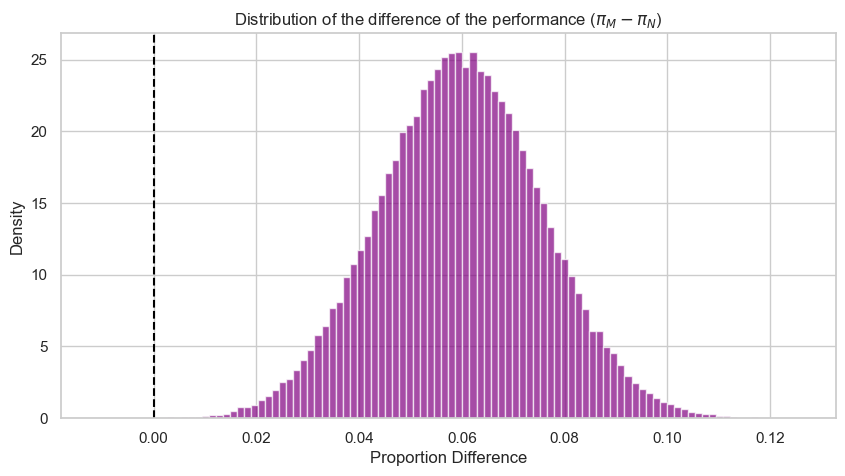

In [13]:
# Number of simulations
n_sims = 100000

# We generate samples from the posterior distributions
samples_M = np.random.beta(alpha_post_M, beta_post_M, n_sims)
samples_N = np.random.beta(alpha_post_N, beta_post_N, n_sims)

# We calculate the probability that having Mirotic on the court improves the efficiency compared to not having him
prob_M_better = np.mean(samples_M > samples_N)

print(f"Probability of Mirotic improving the performance of the team: {prob_M_better:.4%}")

plt.figure(figsize=(10, 5))
plt.hist(samples_M - samples_N, bins=100, color='purple', alpha=0.7, density=True)
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of the difference of the performance ($\pi_M - \pi_N$)')
plt.xlabel('Proportion Difference')
plt.ylabel('Density')
plt.show()

According to this Monte-Carlo simulation, we can be 99.995% sure that when we have Mirotic on court, we have more probability of taking a good shot at the end of a play.

# Hierarchical Model Setup

“Does the team become more efficient with Mirotić on court, overall and in each of the 6 scenarios?”

In this section, a Hierarchical (Multi-level) Bayesian Beta-Binomial model is created to compute the probability that the team is more efficient with Mirotić on the court separately for each scenario/stratum group (e.g., Local games with no clutch time vs. Neutral games with clutch time).

## 1. Theoretical Framework of Hierarchical Logistic Regression

To strictly quantify Nikola Mirotić’s impact on FC Barcelona's offensive efficiency, standard regression models often fall short due to the structured, non-independent nature of sports analytics data. A basketball season is not composed of uniform events; rather, the data is naturally grouped or partitioned into distinct environmental sub-populations, which we call strata (derived from the interaction of court advantages and clutch pressure).

When treating these multi-environment scenarios, a data scientist faces a common statistical dilemma:
+ Complete Pooling (Standard Global Model): Treats all play events as if they come from an identical scenario, disregarding whether a play occurs in a calm local match or under absolute pressure in a neutral-court EuroLeague Final Four. This introduces massive aggregation bias.
+ No Pooling (Independent Strata Models): Treats each of the 6 operational environments as entirely isolated entities. While it respects scenario-specific traits, it heavily suffers from high variance and unreliable estimates for subsets with tiny sample sizes (such as Visitant_1 or Local_1 where $N < 100$).

**The Hierarchical Solution (Partial Pooling)**: Hierarchical Bayesian modeling bridges this gap via partial pooling. Instead of tracking isolated variations or a single over-generalized trait, this framework allows scenario-specific effects to "borrow strength" from each other. The model assumes that while each strategic environment possesses its own specific reality, they all belong to a shared global baseline distribution managed by shared hyper-priors. Consequently, noisy estimates in data-sparse categories are naturally shrunk toward the global mean, reducing overfitting and significantly stabilizing statistical inference.

### Mathematical Definition of Alpha and Beta (The Hierarchical Mapping)

We implement a Hierarchical Logistic Regression where the probability of generating a high-quality offensive sequence ($\pi_i$) is mapped using a logit link function.

For every individual play $i$ belonging to a specific environment stratum $j$ (where $j = 1, \dots, 6$), the structural probability is formalized as follows:
$$\text{logit}(\pi_i) = \alpha_{j[i]} + \beta_{j[i]} \cdot \text{has\_mirotic}_i$$
Where the structural parameters $\alpha$ and $\beta$ are defined as:

+ $\alpha_j$ (Scenario-Specific Intercept / Baseline Efficiency): This parameter captures the baseline log-odds of achieving a successful shot setup (good_shot = 1) in environment $j$ when Nikola Mirotić is not on the floor (has_mirotic = 0). It represents the tactical maturity and baseline execution of the rest of the FC Barcelona roster under varying levels of pressure (e.g., local court without pressure vs. away court under clutch constraints).
+ $\beta_j$ (Scenario-Specific Slope / Mirotić Presence Effect): This parameter directly isolates the marginal impact of having Nikola Mirotić on the floor (has_mirotic = 1) within environment $j$. It reflects how much the log-odds of generating a high-quality shot shift when Mirotić is actively drawing defensive rotations, spacing the floor, or executing under pressure. A positive value ($\beta_j > 0$) implies that his presence actively enhances the offensive process within that specific scenario.

#### Hyper-priors and the Hierarchical Link

To tie these parameters together under a partial-pooling regime, we state that the intercepts and slopes are not fixed constants, but rather random samples drawn from shared overarching global distributions:

$$\alpha_j \sim \mathcal{N}(\mu_\alpha, \sigma_\alpha^2)$$
$$\beta_j \sim \mathcal{N}(\mu_\beta, \sigma_\beta^2)$$

+ $\mu_\alpha$ and $\mu_\beta$ represent the global average baseline efficiency and the global average effect of Mirotić, respectively.
+ $\sigma_\alpha$ and $\sigma_\sigma$ represent the inter-scenario variance, dictating how much tactical flexibility exists across different operational environments.

## 2. Prior choice

In the hierarchical setting, we no longer model a single global proportion directly using a Beta-Binomial model. Instead, we model the probability of generating a good shot through a hierarchical logistic regression.

For each play $i$, we define:

$$
Y_i \sim \operatorname{Bernoulli}(\theta_i)
$$

where:

- $Y_i = 1$ indicates a successful "good shot",
- $Y_i = 0$ otherwise,
- $\theta_i$ is the probability of success for play $i$.

The probability is modeled using a logit link function:

$$
\operatorname{logit}(\theta_i) =
\alpha_{j[i]}
+
\beta_{j[i]} \cdot \text{has\_mirotic}_i
$$

where:

- $\alpha_j$ represents the baseline offensive efficiency for stratum $j$ when Mirotić is not on the court,
- $\beta_j$ measures the impact of Mirotić in stratum $j$,
- $j[i]$ denotes the environmental group corresponding to play $i$.

The six strata considered are Local\_0, Local\_1, Visitant\_0, Visitant\_1, Neutral\_0, Neutral\_1, where the second indicator corresponds to clutch ($1$) or non-clutch ($0$) situations.

### Prior Selection

The previous non-hierarchical analysis showed an overall team success rate of:

$$
p \approx 0.639
$$

Since the logistic regression operates on the log-odds scale, we transform this probability using the logit function:

$$
\operatorname{logit}(0.639) =
\log\left(
\frac{0.639}{1-0.639}
\right)
\approx 0.57
$$

Therefore, the global intercept prior is centered around $0.57$:

$$
\mu_\alpha \sim \mathcal{N}(0.57, 1)
$$

The standard deviation of $1$ provides a weakly informative prior that still allows a wide range of realistic offensive efficiencies.

### Group-Level Variability

To model differences across environmental strata, we use hierarchical priors:

$$
\sigma_\alpha \sim \operatorname{HalfNormal}(0.5)
$$

This prior assumes moderate variability between scenarios while avoiding unrealistically large differences. The group-specific intercepts are defined through a non-centered parametrization:

$$
\alpha_j=
\mu_\alpha
+
\sigma_\alpha \cdot z_{\alpha,j}
$$

with:

$$
z_{\alpha,j} \sim \mathcal{N}(0,1)
$$

### Prior for Mirotić Effect

The observed data suggests that the team performs slightly better offensively when Mirotić is on the court. However, to avoid over-conditioning the model on the observed sample, we choose a weakly informative prior centered at zero:

$$
\mu_\beta \sim \mathcal{N}(0, 0.5)
$$

This reflects the belief that Mirotić may have a moderate positive or negative impact, while letting the data determine the final posterior effect. The variability of Mirotić's impact across game contexts is modeled as:

$$
\sigma_\beta \sim \operatorname{HalfNormal}(0.3)
$$

Finally, the group-specific Mirotić effects are:

$$
\beta_j =
\mu_\beta
+
\sigma_\beta \cdot z_{\beta,j}
$$

where:

$$
z_{\beta,j} \sim \mathcal{N}(0,1)
$$

## 3. Final Hierarchical Model

The complete model can therefore be summarized as:

$$
Y_i \sim \operatorname{Bernoulli}(\theta_i)
$$

$$
\operatorname{logit}(\theta_i) =
\alpha_{j[i]}
+
\beta_{j[i]} \cdot \text{has\_mirotic}_i
$$

$$
\alpha_j=
\mu_\alpha + \sigma_\alpha z_{\alpha,j}
$$

$$
\beta_j=
\mu_\beta + \sigma_\beta z_{\beta,j}
$$

with hierarchical priors:

$$
\mu_\alpha \sim \mathcal{N}(0.57,1)
$$

$$
\sigma_\alpha \sim \operatorname{HalfNormal}(0.5)
$$

$$
\mu_\beta \sim \mathcal{N}(0,0.5)
$$

$$
\sigma_\beta \sim \operatorname{HalfNormal}(0.3)
$$

In [14]:
# Convert the pandas DataFrame columns into raw NumPy arrays (y_obs, has_mirotic_idx, group_mapping)
# Print out the 6 distinct operational strata groups (Local_0, Visitant_0, etc.)
# Organize the dataset into vectors that PyMC can map efficiently. 

y_obs = df['good_shot'].values
has_mirotic_idx = df['has_mirotic'].values

# Matches every single one of the 3,642 plays to its respective environmental index (0 through 5) 
# so that the hierarchical model knows which baseline group intercept ($\alpha_j$) to apply to which play
group_mapping = group_idx

num_groups = len(group_names)

print(f"Target Observations (Plays): {len(y_obs)}")
print(f"Hierarchical Stratum Groups Available: {num_groups} {list(group_names)}")

Target Observations (Plays): 3642
Hierarchical Stratum Groups Available: 6 ['Local_0', 'Visitant_0', 'Visitant_1', 'Local_1', 'Neutral_1', 'Neutral_0']


## 4. Compilation in PyMC

+ $\alpha$ = how good the team’s shots are in that scenario without Mirotić.
+ $\beta$ = how much Mirotić changes that baseline when he is on the court.

In [15]:
with pm.Model(coords={"groups": group_names}) as hierarchical_model:
    
    # Setup and Stratum Intercepts (The Baseline Advantage)
    # Computes the unique baseline probability of scoring a "good shot" for each of your 6 game environments
    mu_a = pm.Normal('mu_a', mu=0.57, sigma=1.0)
    sigma_a = pm.HalfNormal('sigma_a', sigma=0.5)
    a_offset = pm.Normal('a_offset', mu=0, sigma=1.0, shape=num_groups)
    alpha = pm.Deterministic('alpha', mu_a + sigma_a * a_offset, dims="groups")
    
    # Hyper-priors for group-specific Mirotic effects
    # Calculates 6 distinct Mirotić parameters—one for each scenario.
    mu_b = pm.Normal('mu_b', mu=0, sigma=0.5)          # global average Mirotic effect (all games)
    sigma_b = pm.HalfNormal('sigma_b', sigma=0.3)      # variability across strata
    b_offset = pm.Normal('b_offset', mu=0, sigma=1.0, shape=num_groups)
    beta_mirotic = pm.Deterministic(
        'beta_mirotic',
        mu_b + sigma_b * b_offset,
        dims="groups"
    )
    
    # Linear predictor: group-specific intercept + group-specific Mirotic effect
    logit_theta = alpha[group_idx] + beta_mirotic[group_idx] * has_mirotic_idx
    
    # Likelihood
    y_likelihood = pm.Bernoulli('y_obs', logit_p=logit_theta, observed=y_obs)

To translate from the mathematical formulas into actual posterior probability samples.

In [16]:
# Sample the posterior distribution using the NUTS sampler
# Execute the NUTS to draw 2000 samples across 4 chains from the posterior distribution
# Computes the log-likelihood values

with hierarchical_model:
    idata_hierarchical = pm.sample(
        draws=2000, 
        tune=1000, 
        chains=4, 
        random_seed=RANDOM_SEED, 
        return_inferencedata=True,
        target_accept=0.99
    )

    # Compute log-likelihood values to facilitate WAIC/LOO cross-validation comparisons
    pm.compute_log_likelihood(idata_hierarchical)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_a, sigma_a, a_offset, mu_b, sigma_b, b_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 210 seconds.


Output()

## 5. Summaries

In [17]:
# Summary metrics for checking convergence parameters (R-hat, Ess) and parameters behavior

summary_hier = az.summary(
    idata_hierarchical,
    var_names=['mu_a', 'sigma_a', 'mu_b', 'sigma_b', 'beta_mirotic', 'alpha']
)
display(summary_hier)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,0.407,0.120,0.156,0.622,0.002,0.002,3225.0,3279.0,1.0
sigma_a,0.182,0.151,0.000,0.448,0.003,0.002,1823.0,3089.0,1.0
mu_b,0.283,0.137,0.028,0.551,0.003,0.002,2996.0,3621.0,1.0
sigma_b,0.221,0.135,0.000,0.446,0.003,0.001,2152.0,2291.0,1.0
beta_mirotic[Local_0],0.338,0.095,0.163,0.521,0.001,0.001,8678.0,6745.0,1.0
beta_mirotic[Visitant_0],0.468,0.205,0.112,0.853,0.003,0.002,3541.0,6329.0,1.0
beta_mirotic[Visitant_1],0.417,0.233,0.010,0.872,0.003,0.003,5042.0,6727.0,1.0
beta_mirotic[Local_1],0.273,0.194,-0.072,0.673,0.002,0.002,7072.0,6599.0,1.0
beta_mirotic[Neutral_1],0.175,0.101,-0.019,0.359,0.001,0.001,5882.0,6842.0,1.0
beta_mirotic[Neutral_0],0.086,0.234,-0.383,0.476,0.004,0.002,2878.0,5753.0,1.0


### Interpret results

The hierarchical logistic model suggests that Nikola Mirotić generally improves offensive efficiency, measured as the probability of generating a good shot. The global effect parameter was positive: $\mu_b = 0.283 \quad \text{HDI } [0.028,\;0.551]$, indicating an overall positive contribution across game environments.

The strongest and most reliable effects were observed in the \texttt{Local\_0} and \texttt{Visitant\_0} strata: $\beta_{\text{Local\_0}} = 0.338$ and $\text{HDI } [0.163,\;0.521]$. $\beta_{\text{Visitant\_0}} = 0.468$ and $\text{HDI } [0.112,\;0.853]$.

Since these intervals exclude zero, the posterior strongly supports improved shot efficiency when Mirotić is on the court in these contexts. The largest estimated effect appears in away-game situations (\texttt{Visitant\_0}), suggesting that Mirotić may provide additional offensive stability under more difficult competitive environments. 

The effect remains positive but more uncertain in \texttt{Visitant\_1}: $\beta_{\text{Visitant\_1}} = 0.417$ and $\text{HDI } [0.010,\;0.872]$, while other strata showed weaker or inconclusive evidence: 
+ $\beta_{\text{Local\_1}} = 0.273$ and $\text{HDI } [-0.072,\;0.673]$
+ $\beta_{\text{Neutral\_1}} = 0.175$ and $\text{HDI } [-0.019,\;0.359]$
+ $\beta_{\text{Neutral\_0}} = 0.086$ and $\text{HDI } [-0.383,\;0.476]$.

Because these intervals overlap zero, the evidence for a positive Mirotić effect in neutral-court and some local contexts is substantially weaker.

The hierarchical variance parameter, $\sigma_b = 0.221$ indicates meaningful variation across strata, confirming that Mirotić's impact depends on the game environment rather than remaining constant across all situations.

Finally, convergence diagnostics were excellent ($\hat{R}=1.0$) for all parameters with high effective sample sizes), indicating stable posterior estimation and reliable inference.

In [18]:
# Now compute the posterior probability that Mirotić improves efficiency in each scenario:

posterior = idata_hierarchical.posterior

# Stack chains and draws for convenience
beta_samples = posterior['beta_mirotic'].stack(draws=("chain", "draw"))  # (groups, draws)
mu_b_samples = posterior['mu_b'].stack(draws=("chain", "draw"))          # (draws,)

# Probability that Mirotic helps in each stratum: P(beta_j > 0)
prob_beta_pos_groups = (beta_samples > 0).mean(dim="draws").values  # numpy array length num_groups

# Global (all games) probability: P(mu_b > 0)
prob_beta_pos_global = float((mu_b_samples > 0).mean(dim="draws"))

print("P(Mirotic improves efficiency | all games) =", prob_beta_pos_global)
for name, p in zip(group_names, prob_beta_pos_groups):
    print(f"P(Mirotic improves efficiency | {name}) = {p}")

P(Mirotic improves efficiency | all games) = 0.978
P(Mirotic improves efficiency | Local_0) = 0.99975
P(Mirotic improves efficiency | Visitant_0) = 0.9965
P(Mirotic improves efficiency | Visitant_1) = 0.9835
P(Mirotic improves efficiency | Local_1) = 0.9235
P(Mirotic improves efficiency | Neutral_1) = 0.9585
P(Mirotic improves efficiency | Neutral_0) = 0.666


In [19]:
nice_labels = {
    'Visitant_1': 'Visitant & Clutch',
    'Local_1': 'Local & Clutch',
    'Neutral_1': 'Neutral & Clutch',
    'Visitant_0': 'Visitant & Non-clutch',
    'Local_0': 'Local & Non-clutch',
    'Neutral_0': 'Neutral & Non-clutch'
}
labels_ordered = [nice_labels[g] for g in group_names]

## 6. Visualization and summary - Mirotic on the court

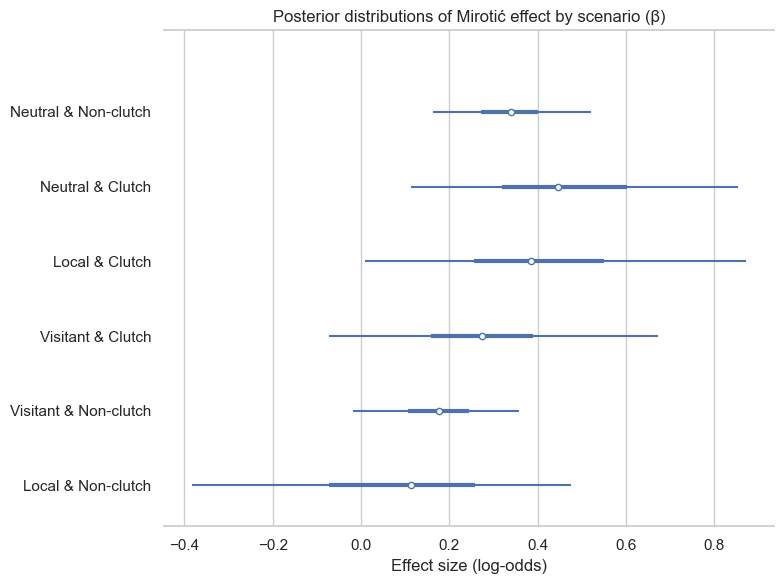

In [20]:
# Forest plot of β (Mirotić effect per group)

fig, ax = plt.subplots(figsize=(8, 6))

az.plot_forest(
    idata_hierarchical,
    var_names=["beta_mirotic"],
    combined=True,
    hdi_prob=0.94,
    ax=ax
)

# Replace the y‑axis labels with your nicer labels
ax.set_yticklabels(labels_ordered)

plt.title("Posterior distributions of Mirotić effect by scenario (β)")
plt.xlabel("Effect size (log-odds)")
plt.tight_layout()
plt.show()


# If the entire interval is above 0, the effect is positive with high certainty.
# If the interval crosses 0, the effect is uncertain.
# If the interval is mostly above 0, but touches 0, the effect is likely positive but not guaranteed.

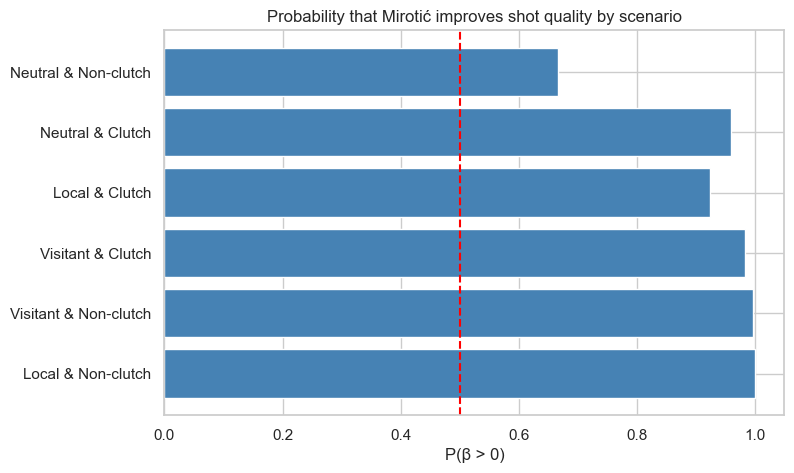

In [21]:
# Probability that β > 0 per group

probs = prob_beta_pos_groups
plt.figure(figsize=(8,5))
plt.barh(labels_ordered, probs, color="steelblue")
plt.axvline(0.5, color="red", linestyle="--")
plt.xlabel("P(β > 0)")
plt.title("Probability that Mirotić improves shot quality by scenario")
plt.show()

probs = prob_beta_pos_groups

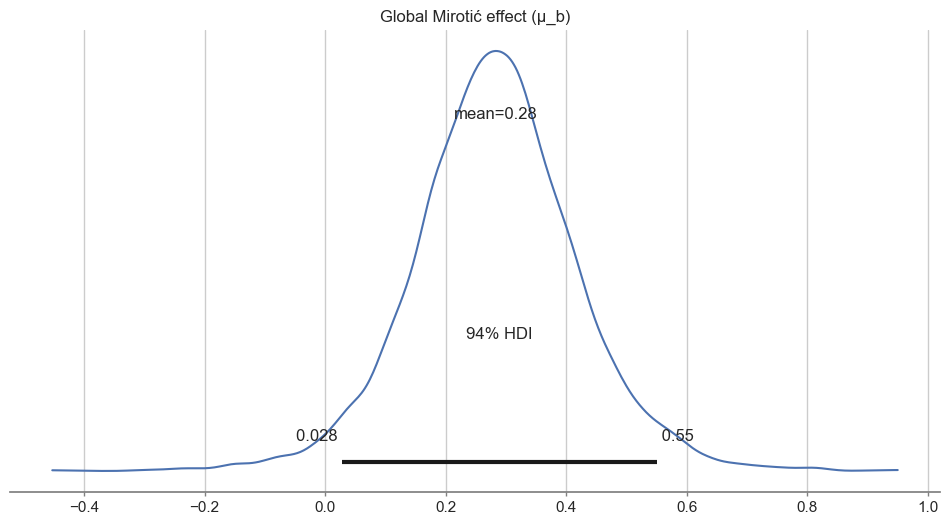

In [22]:
# Global effect distribution (μ_b)

az.plot_posterior(
    idata_hierarchical,
    var_names=["mu_b"],
    hdi_prob=0.94
)
plt.title("Global Mirotić effect (μ_b)")
plt.show()

### Final Summary

In [25]:
# Create a new markdown cell for the summary if you like, then paste this code:

# 1. Overall probability across the entire hyper-prior (global effect)
mu_beta_samples = idata_hierarchical.posterior["mu_b"].values.flatten()
prob_overall_positive = (mu_beta_samples > 0).mean()

print("=" * 60)
print("     SUMMARY: PROBABILITY THAT MIROTIĆ IMPROVES EFFICIENCY")
print("=" * 60)
print(f"Overall Global Probability: {prob_overall_positive * 100:.2f}%\n")
print("-" * 60)
print("Scenario-Specific Probabilities:")
print("-" * 60)

# 2. Extract scenario-specific probabilities
beta_samples = idata_hierarchical.posterior["beta_mirotic"].values

# We assume 'labels_ordered' from your plotting cell contains the names of the scenarios
for idx, scenario_name in enumerate(labels_ordered):
    # Extract samples for this specific scenario across all chains and draws
    scenario_beta_samples = beta_samples[:, :, idx].flatten()
    
    # Calculate the probability that the effect is greater than 0
    prob_positive = (scenario_beta_samples > 0).mean()
    
    print(f"• When {scenario_name:<25} : {prob_positive * 100:.2f}%")
print("=" * 60)

     SUMMARY: PROBABILITY THAT MIROTIĆ IMPROVES EFFICIENCY
Overall Global Probability: 97.80%

------------------------------------------------------------
Scenario-Specific Probabilities:
------------------------------------------------------------
• When Local & Non-clutch        : 99.98%
• When Visitant & Non-clutch     : 99.65%
• When Visitant & Clutch         : 98.35%
• When Local & Clutch            : 92.35%
• When Neutral & Clutch          : 95.85%
• When Neutral & Non-clutch      : 66.60%


## 7. Visualization and summary - alpha

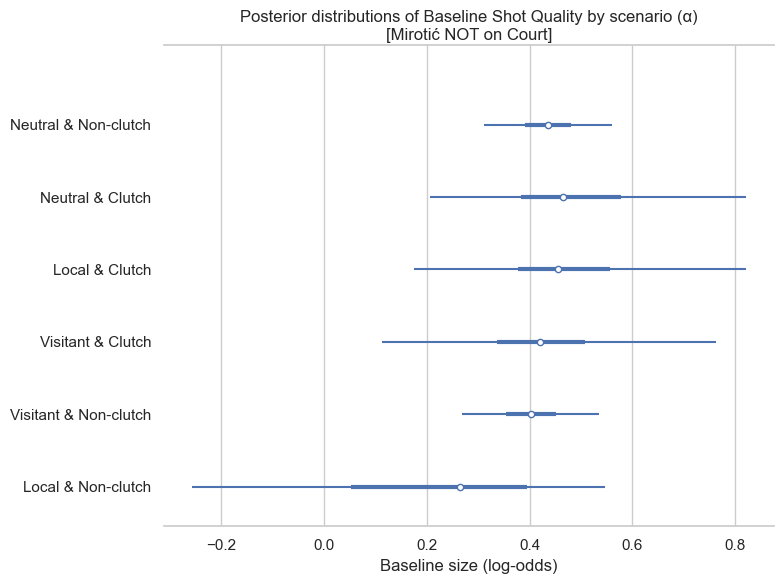

In [26]:
import scipy.special as sp

fig, ax = plt.subplots(figsize=(8, 6))

az.plot_forest(
    idata_hierarchical,
    var_names=["alpha"],
    combined=True,
    hdi_prob=0.94,
    ax=ax
)

# Replace the y‑axis labels with your nicer labels
ax.set_yticklabels(labels_ordered)

plt.title("Posterior distributions of Baseline Shot Quality by scenario (α)\n[Mirotić NOT on Court]")
plt.xlabel("Baseline size (log-odds)")
plt.tight_layout()
plt.show()

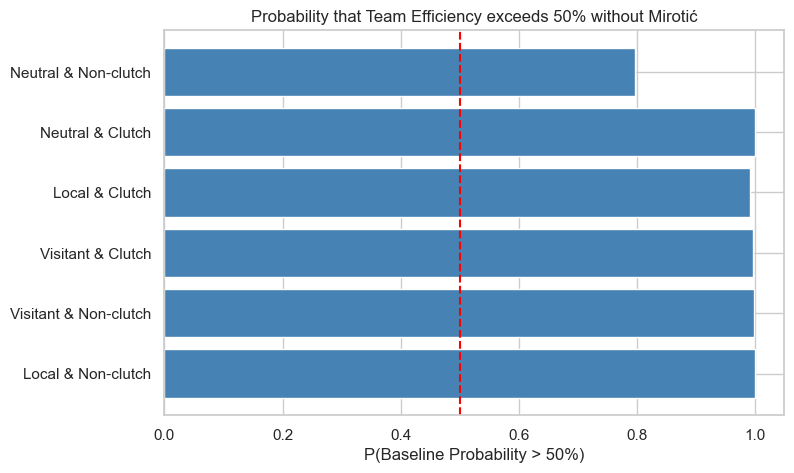

In [31]:
# BAR CHART: PROBABILITY OF EXCELLING (Baseline Probability > 50%)

# Extract alpha samples and convert them to the real probability scale (0 to 1)
alpha_samples = idata_hierarchical.posterior["alpha"].values
prob_alpha_samples = sp.expit(alpha_samples) # Inverse-logit conversion

# Calculate the probability that the baseline shot success rate is above 50%
prob_above_50_groups = []
for idx in range(len(labels_ordered)):
    scenario_prob_samples = prob_alpha_samples[:, :, idx].flatten()
    prob_above_50 = (scenario_prob_samples > 0.50).mean()
    prob_above_50_groups.append(prob_above_50)

plt.figure(figsize=(8,5))
plt.barh(labels_ordered, prob_above_50_groups, color="steelblue")
plt.axvline(0.5, color="red", linestyle="--")
plt.xlabel("P(Baseline Probability > 50%)")
plt.title("Probability that Team Efficiency exceeds 50% without Mirotić")
plt.show()

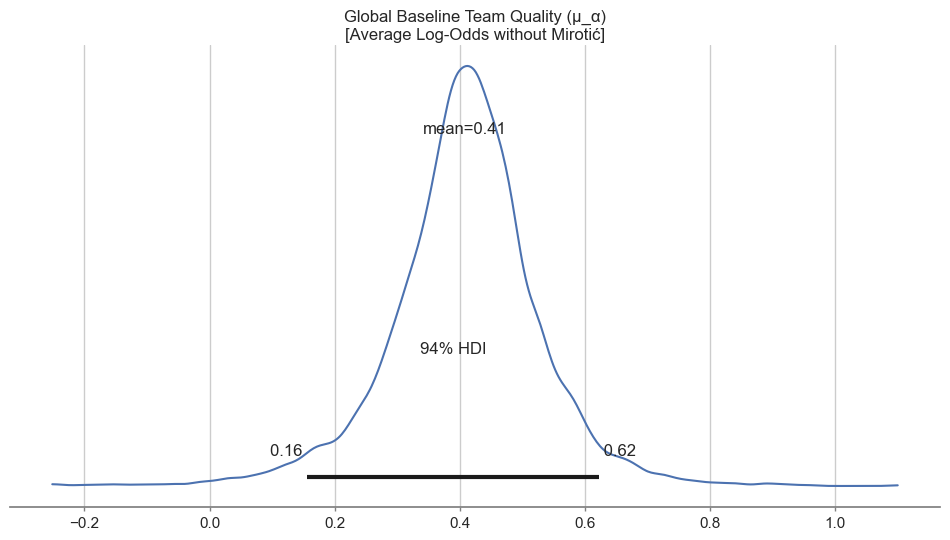

In [28]:
# 3. GLOBAL BASELINE DISTRIBUTION (μ_α)

# Note: check if your model used 'mu_a' or 'mu_alpha' in your PyMC setup
# Assuming 'mu_alpha' based on typical naming setups
global_alpha_var = "mu_alpha" if "mu_alpha" in idata_hierarchical.posterior else "mu_a"

az.plot_posterior(
    idata_hierarchical,
    var_names=[global_alpha_var],
    hdi_prob=0.94
)
plt.title("Global Baseline Team Quality (μ_α)\n[Average Log-Odds without Mirotić]")
plt.show()

### Final Summary

In [30]:
# 1. Overall average global baseline (converted to probability)
mu_alpha_samples = idata_hierarchical.posterior[global_alpha_var].values.flatten()
global_baseline_prob_mean = sp.expit(mu_alpha_samples).mean()

print("=" * 60)
print("     SUMMARY: TEAM OFFENSIVE EFFICIENCY WITHOUT MIROTIĆ")
print("=" * 60)
print(f"Overall Global Baseline Success Rate: {global_baseline_prob_mean * 100:.2f}%\n")
print("-" * 60)
print("Scenario-Specific Expected Efficiencies (When Mirotić is resting):")
print("-" * 60)

# 2. Extract and print scenario-specific baseline probabilities
for idx, scenario_name in enumerate(labels_ordered):
    # Extract alpha samples for this scenario and convert to probability scale
    scenario_alpha_samples = alpha_samples[:, :, idx].flatten()
    scenario_probs = sp.expit(scenario_alpha_samples)
    
    # Calculate key descriptive stats
    mean_prob = scenario_probs.mean() * 100
    hdi_lower, hdi_upper = np.percentile(scenario_probs, [3, 97]) * 100 # 94% HDI range
    
    print(f"• {scenario_name:<25} : {mean_prob:.2f}% expected success  (94% HDI: {hdi_lower:.1f}% to {hdi_upper:.1f}%)")
print("=" * 60)

     SUMMARY: TEAM OFFENSIVE EFFICIENCY WITHOUT MIROTIĆ
Overall Global Baseline Success Rate: 60.00%

------------------------------------------------------------
Scenario-Specific Expected Efficiencies (When Mirotić is resting):
------------------------------------------------------------
• Local & Non-clutch        : 60.75% expected success  (94% HDI: 57.9% to 63.8%)
• Visitant & Non-clutch     : 61.85% expected success  (94% HDI: 55.3% to 69.7%)
• Visitant & Clutch         : 61.60% expected success  (94% HDI: 54.7% to 69.8%)
• Local & Clutch            : 60.36% expected success  (94% HDI: 52.8% to 68.1%)
• Neutral & Clutch          : 59.90% expected success  (94% HDI: 56.7% to 63.1%)
• Neutral & Non-clutch      : 55.17% expected success  (94% HDI: 42.5% to 62.8%)


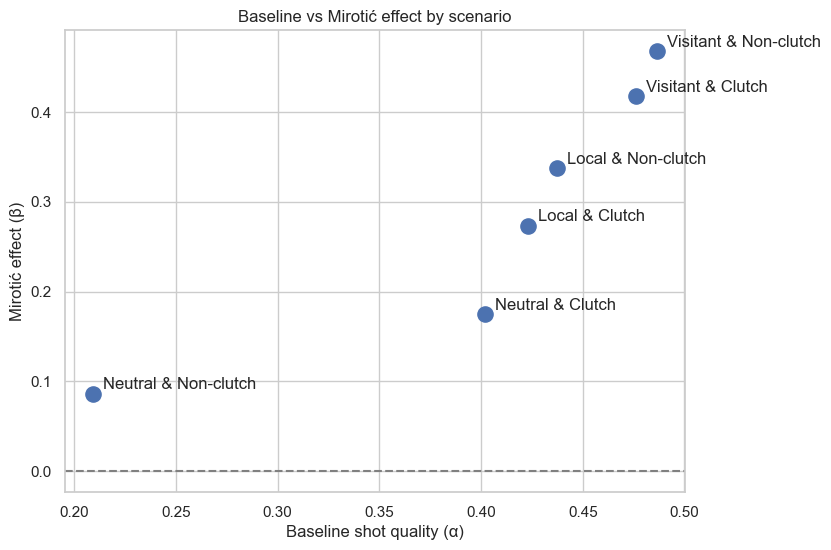

In [32]:
# Combined visualization: β vs α
# This plot shows whether Mirotić helps more in low‑baseline or high‑baseline contexts.

alpha_means = idata_hierarchical.posterior["alpha"].mean(dim=("chain","draw")).values
beta_means = idata_hierarchical.posterior["beta_mirotic"].mean(dim=("chain","draw")).values

plt.figure(figsize=(8,6))
plt.scatter(alpha_means, beta_means, s=120)

for i, label in enumerate(labels_ordered):
    plt.text(alpha_means[i]+0.005, beta_means[i]+0.005, label)

plt.xlabel("Baseline shot quality (α)")
plt.ylabel("Mirotić effect (β)")
plt.title("Baseline vs Mirotić effect by scenario")
plt.axhline(0, color="gray", linestyle="--")
plt.show()